# Flight Delay Analysis - USA 2015
## Objective: Analyze flight delay patterns across airlines,airports and months
### Dataset: 5.8 million US flight from 2015

In [27]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
df = pd.read_csv(r'C:\Users\Dell\Documents\flights.csv')
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.shape

(5819079, 31)

In [19]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [20]:
df[['AIRLINE','DEPARTURE_DELAY','ARRIVAL_DELAY','CANCELLED']].describe()

,DEPARTURE_DELAY,ARRIVAL_DELAY,CANCELLED
count,5.732926e+06,5.714008e+06,5.819079e+06
mean,9.370158e+00,4.407057e+00,1.544643e-02
std,3.708094e+01,3.927130e+01,1.233201e-01
min,-8.200000e+01,-8.700000e+01,0.000000e+00
25%,-5.000000e+00,-1.300000e+01,0.000000e+00
50%,-2.000000e+00,-5.000000e+00,0.000000e+00
75%,7.000000e+00,8.000000e+00,0.000000e+00
max,1.988000e+03,1.971000e+03,1.000000e+00


In [21]:
df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)

AIRLINE
NK    15.944766
UA    14.435441
F9    13.350858
B6    11.514353
WN    10.581986
MQ    10.125188
VX     9.022595
AA     8.900856
EV     8.715934
OO     7.801104
DL     7.369254
US     6.141137
AS     1.785801
HA     0.485713
Name: DEPARTURE_DELAY, dtype: float64

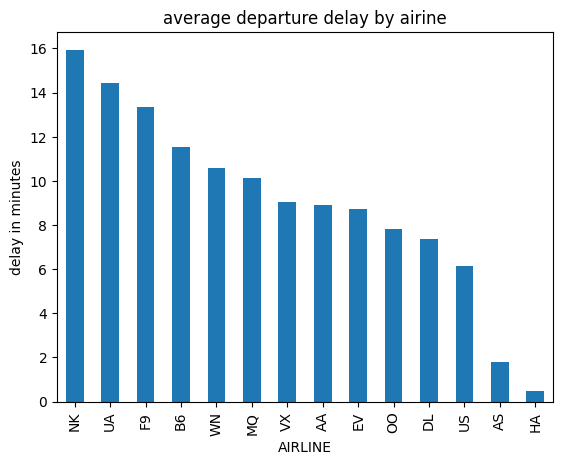

In [22]:
import matplotlib.pyplot as plt
df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('average departure delay by airine')
plt.ylabel('delay in minutes')
plt.show()

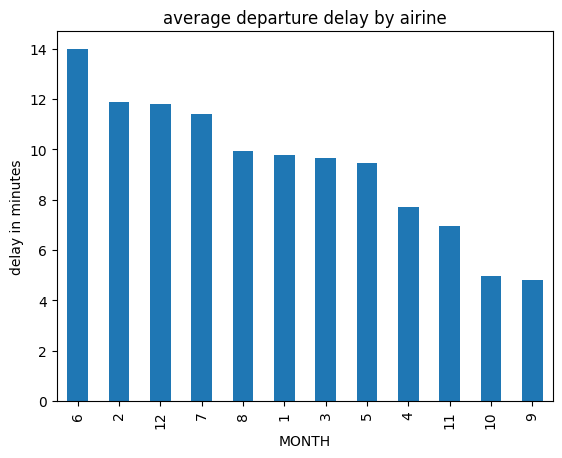

In [23]:
import matplotlib.pyplot as plt
df.groupby('MONTH')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('average departure delay by airine')
plt.ylabel('delay in minutes')
plt.show()

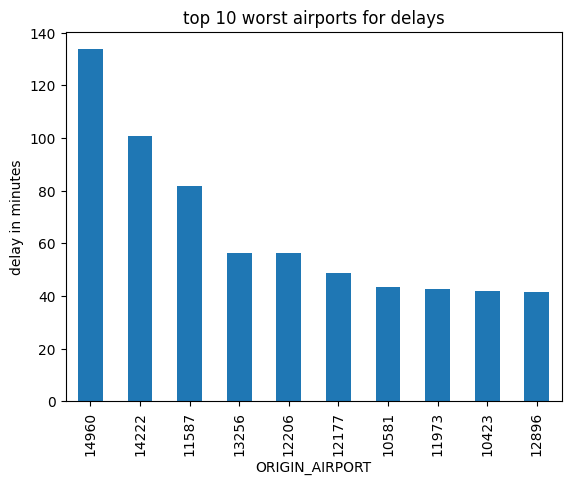

In [24]:
import matplotlib.pyplot as plt
df.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('top 10 worst airports for delays')
plt.ylabel('delay in minutes')
plt.show()

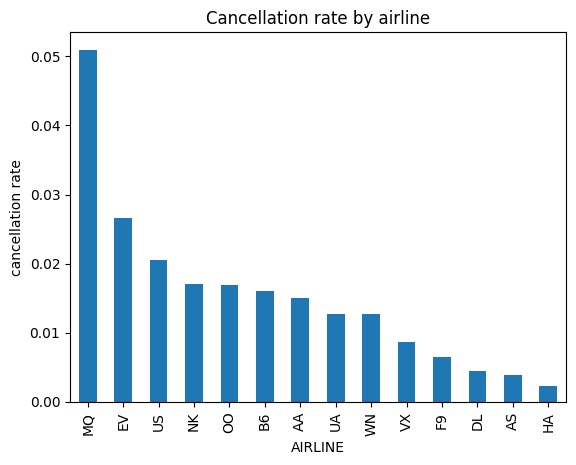

In [25]:
import matplotlib.pyplot as plt
df.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Cancellation rate by airline')
plt.ylabel('cancellation rate')
plt.show()

In [13]:
df[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].mean()

AIR_SYSTEM_DELAY       13.480568
SECURITY_DELAY          0.076154
AIRLINE_DELAY          18.969547
LATE_AIRCRAFT_DELAY    23.472838
WEATHER_DELAY           2.915290
dtype: float64

df[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].mean().plot(kind='bar')
plt.title('average delay by reason')
plt.ylabel('minutes')
plt.show()